<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Write your code here to read the data
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Content/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
df.head()
df


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [18]:
# Write your code here
df.shape





(1898, 9)

#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Write your code here
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
Data Types = integer, strings, float

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Write your code here
df.isnull().sum

<bound method DataFrame.sum of       order_id  customer_id  restaurant_name  cuisine_type  cost_of_the_order  \
0        False        False            False         False              False   
1        False        False            False         False              False   
2        False        False            False         False              False   
3        False        False            False         False              False   
4        False        False            False         False              False   
...        ...          ...              ...           ...                ...   
1893     False        False            False         False              False   
1894     False        False            False         False              False   
1895     False        False            False         False              False   
1896     False        False            False         False              False   
1897     False        False            False         False              False   

      day_of_the_week  rating  food_preparation_time  delivery_time  
0               False   False                  False          False  
1               False   False                  False          False  
2               False   False                  False          False  
3               False   False                  False          False  
4               False   False                  False          False  
...               ...     ...                    ...            ...  
1893            False   False                  False          False  
1894            False   False                  False          False  
1895            False   False                  False          False  
1896            False   False                  False          False  
1897            False   False                  False          False  

[1898 rows x 9 columns]>

#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

#### Observations:
                   the minimum food preparation is 20 min.
                   the average (mean) took 27.37 min while
                   the max took 35 min to prepare food.



In [22]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


### **Question 5:** How many orders are not rated? [1 mark]

In [23]:
df['rating'].value_counts()


,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:
                  there are 736 orders that are not rated


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

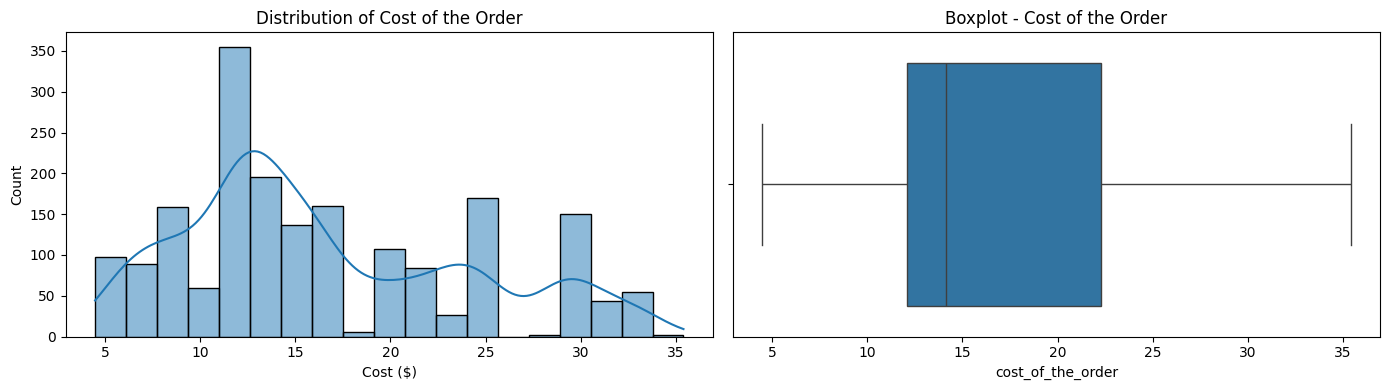

Median cost: $ 14.14
Mean cost:   $ 16.5


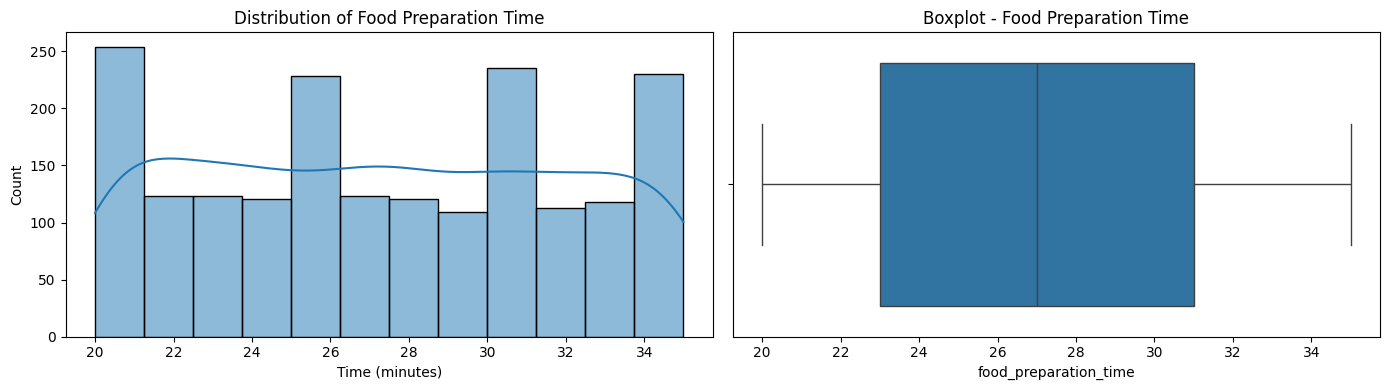

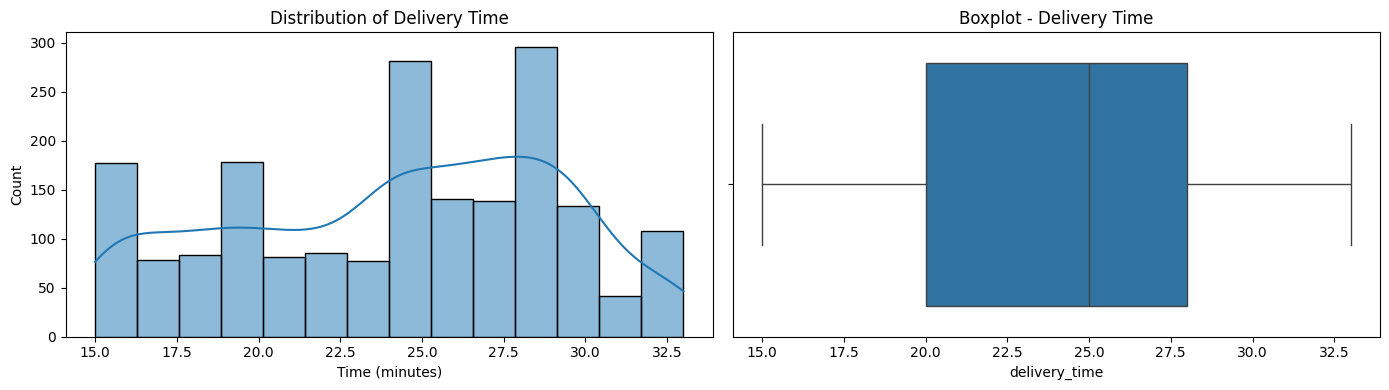

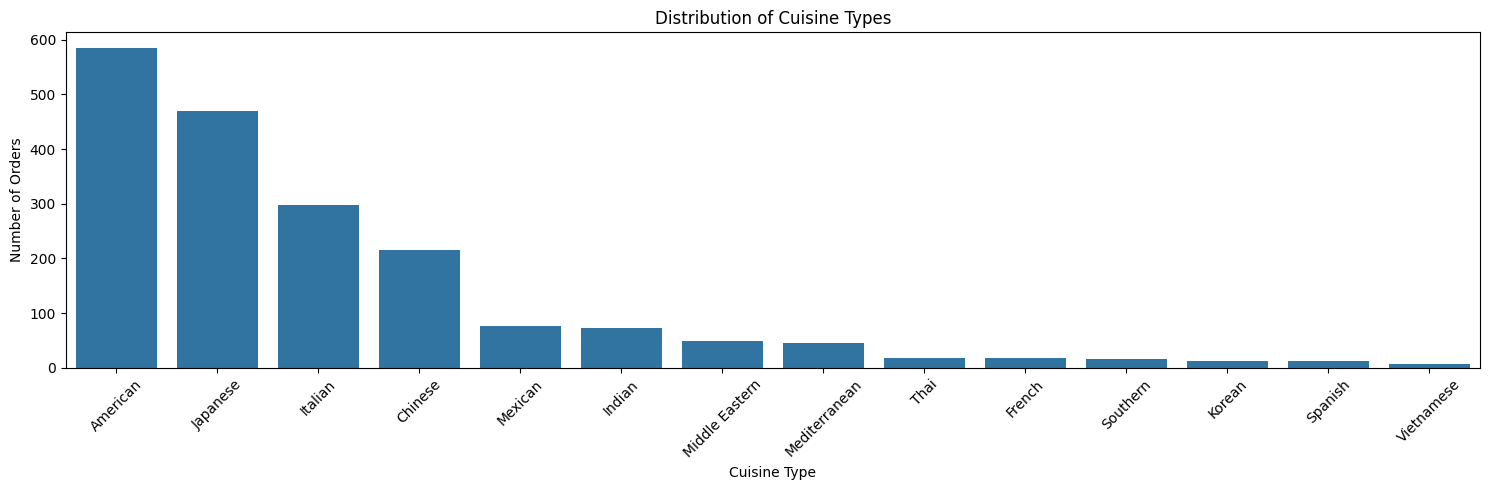

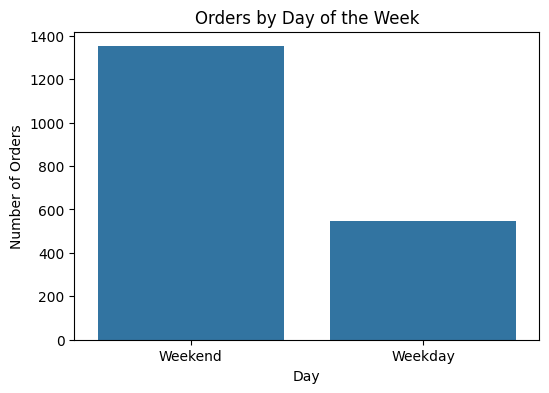

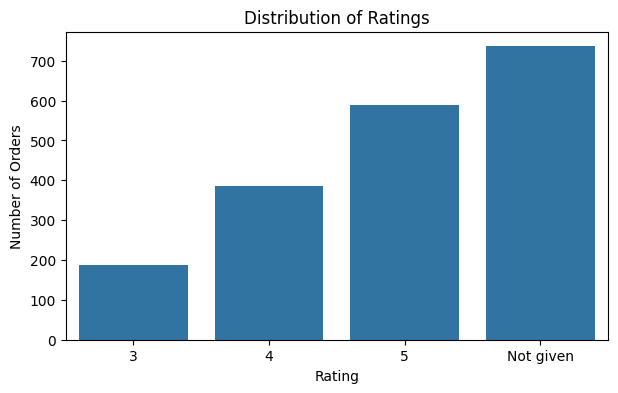

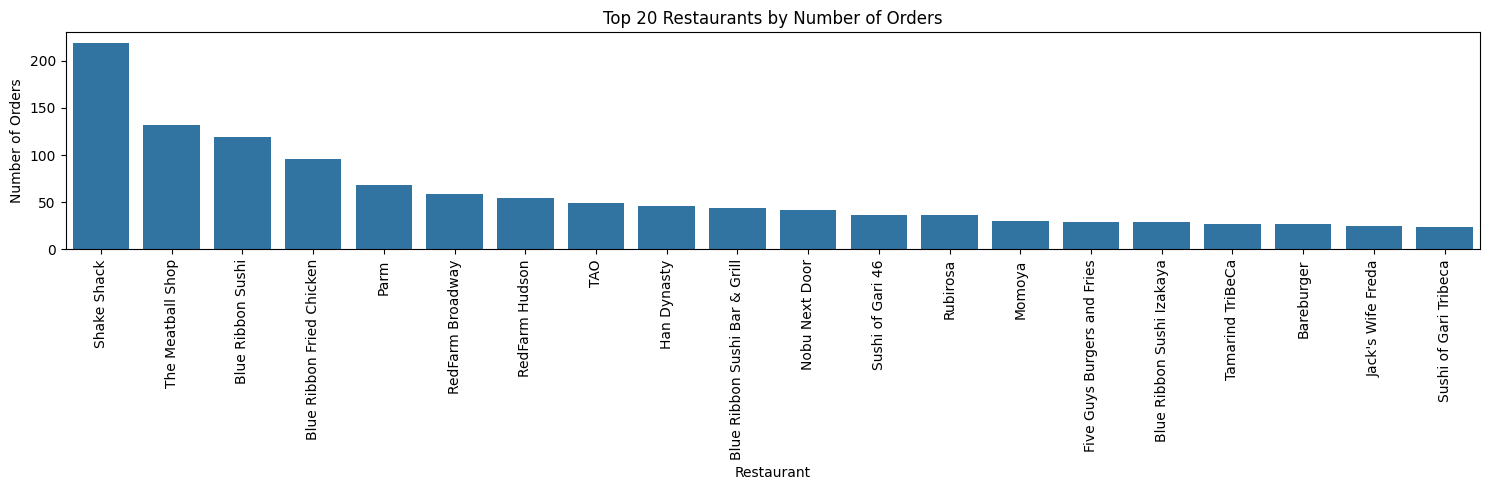

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. NUMERICAL VARIABLES: cost_of_the_order ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='cost_of_the_order', ax=axes[0], kde=True)
axes[0].set_title('Distribution of Cost of the Order')
axes[0].set_xlabel('Cost ($)')

sns.boxplot(data=df, x='cost_of_the_order', ax=axes[1])
axes[1].set_title('Boxplot - Cost of the Order')

plt.tight_layout()
plt.show()

print('Median cost: $', df['cost_of_the_order'].median())
print('Mean cost:   $', round(df['cost_of_the_order'].mean(), 2))
# ── 2. NUMERICAL VARIABLES: food_preparation_time ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='food_preparation_time', ax=axes[0], kde=True)
axes[0].set_title('Distribution of Food Preparation Time')
axes[0].set_xlabel('Time (minutes)')

sns.boxplot(data=df, x='food_preparation_time', ax=axes[1])
axes[1].set_title('Boxplot - Food Preparation Time')

plt.tight_layout()
plt.show()
# ── 3. NUMERICAL VARIABLES: delivery_time ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='delivery_time', ax=axes[0], kde=True)
axes[0].set_title('Distribution of Delivery Time')
axes[0].set_xlabel('Time (minutes)')

sns.boxplot(data=df, x='delivery_time', ax=axes[1])
axes[1].set_title('Boxplot - Delivery Time')

plt.tight_layout()
plt.show()
# ── 4. CATEGORICAL VARIABLE: cuisine_type ────────────────────────────────────
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='cuisine_type',
              order=df['cuisine_type'].value_counts().index)
plt.title('Distribution of Cuisine Types')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Removed: print(df['cuisine_type'].value_counts())
# ── 5. CATEGORICAL VARIABLE: day_of_the_week ─────────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='day_of_the_week')
plt.title('Orders by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.show()

# Removed: print(df['day_of_the_week'].value_counts())
# ── 6. CATEGORICAL VARIABLE: rating ──────────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='rating', order=['3', '4', '5', 'Not given'])
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

# Removed: print(df['rating'].value_counts())
# ── 7. CATEGORICAL VARIABLE: restaurant_name ─────────────────────────────────
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='restaurant_name',
              order=df['restaurant_name'].value_counts().head(20).index)
plt.title('Top 20 Restaurants by Number of Orders')
plt.xlabel('Restaurant')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Write the code here

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [28]:
# Write the code here
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [32]:
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


#### Observations:
                 The most popular cuisine on weekends is the American @415


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [34]:
# Calculate the percentage of orders that cost more than 20 dollars
percentage_cost_gt_20 = (df['cost_of_the_order'] > 20).mean() * 100
print(f"{percentage_cost_gt_20:.2f}% of orders cost more than 20 dollars.")

29.24% of orders cost more than 20 dollars.


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [37]:
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
                 24.16 is the mean order delivery time


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [38]:
# Write the code here
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


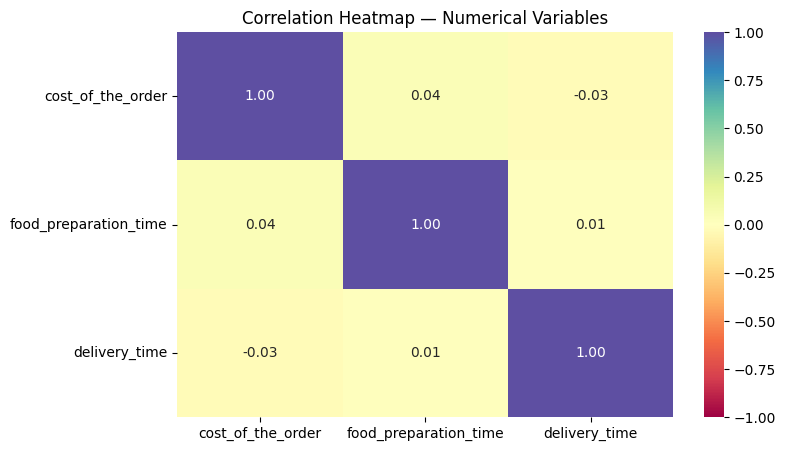

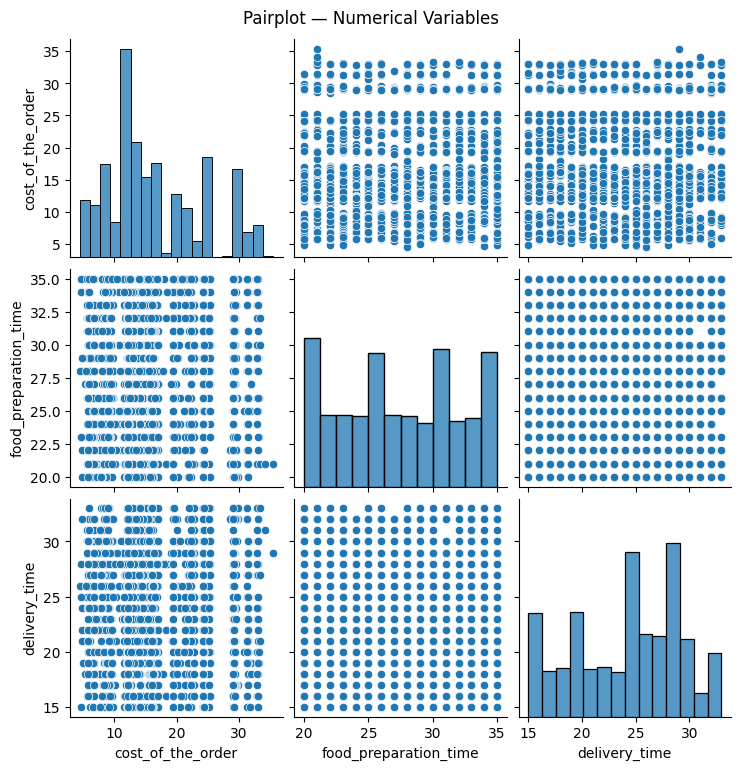

/tmp/ipykernel_12240/1851395554.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df, palette='PuBu')


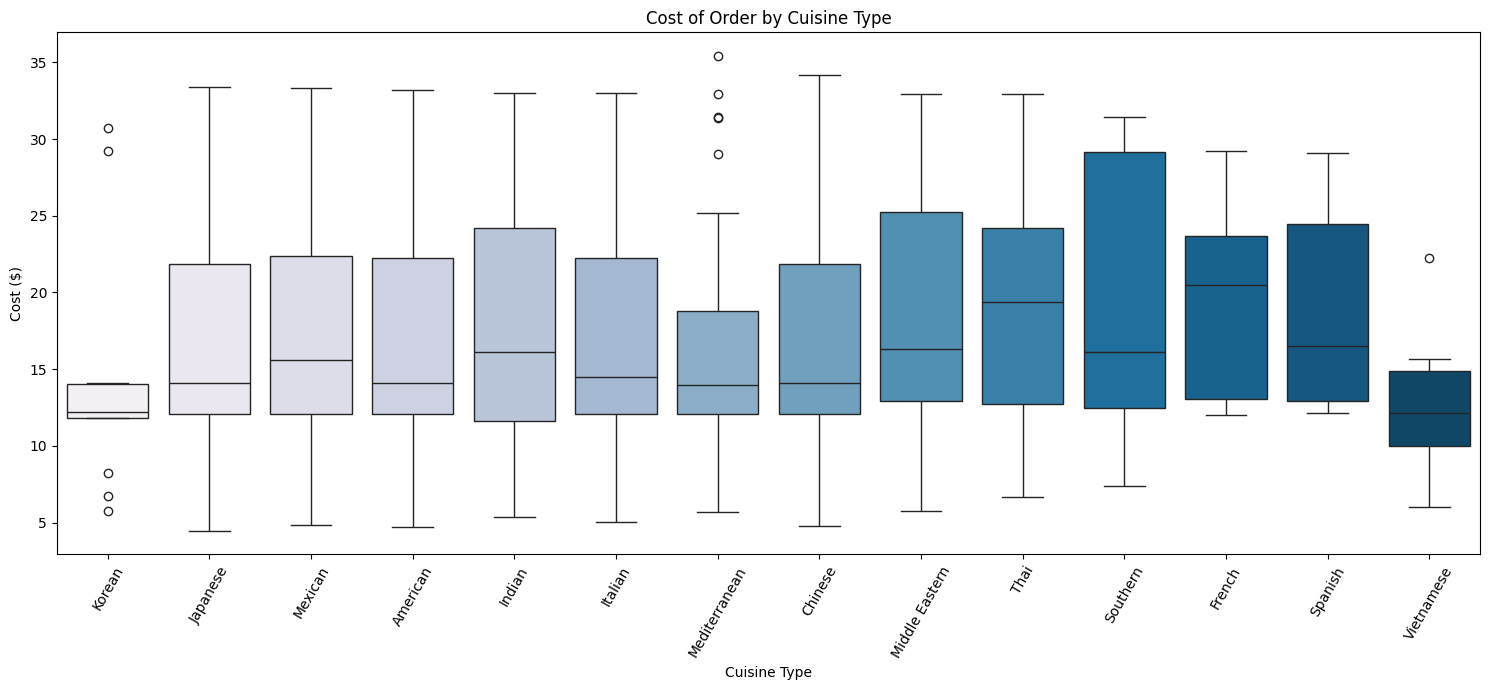

/tmp/ipykernel_12240/1851395554.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df, palette='PuBu')


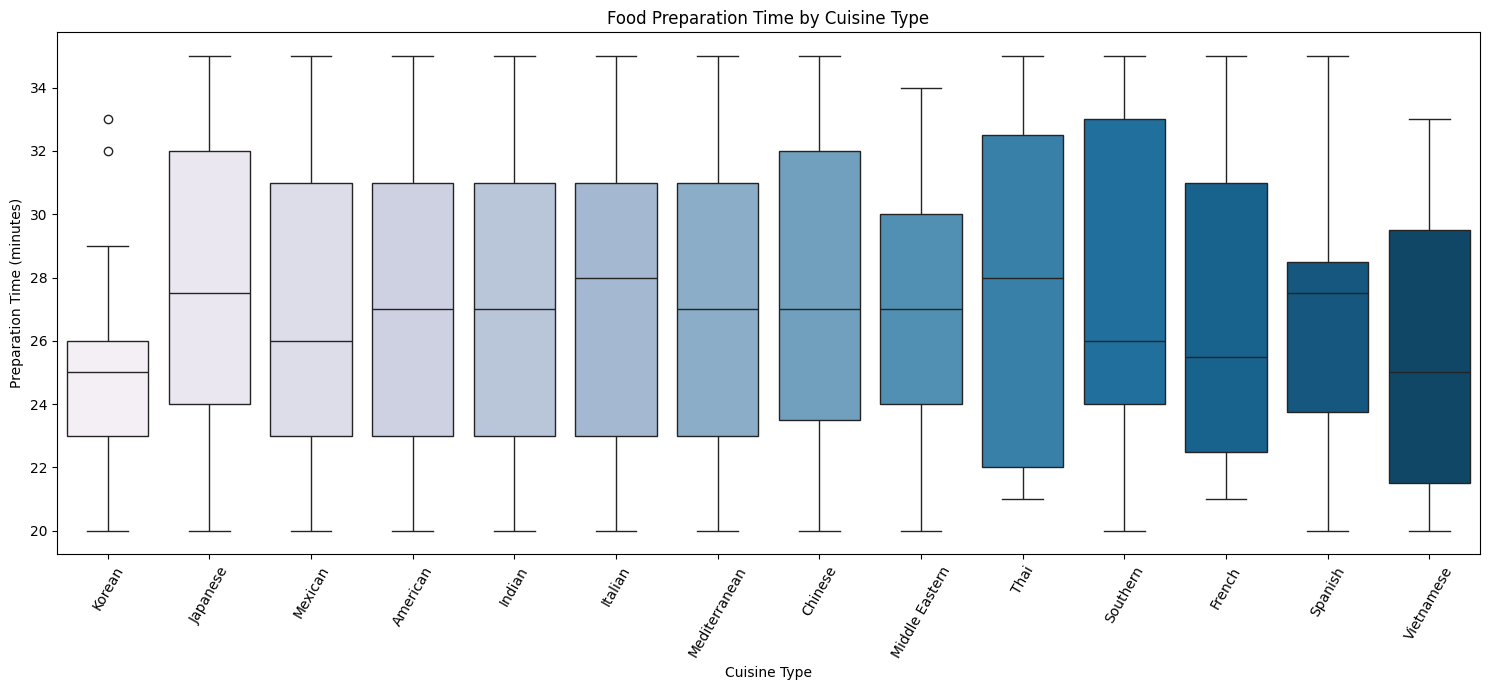

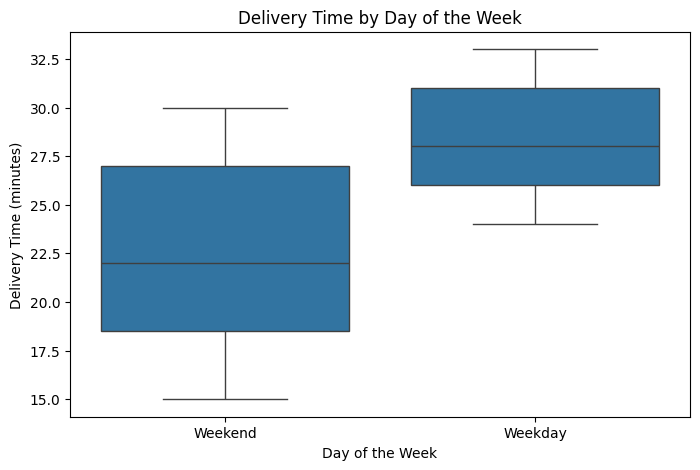

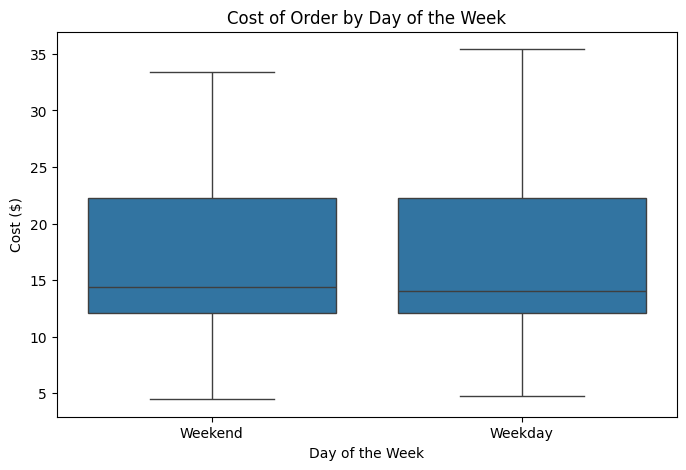

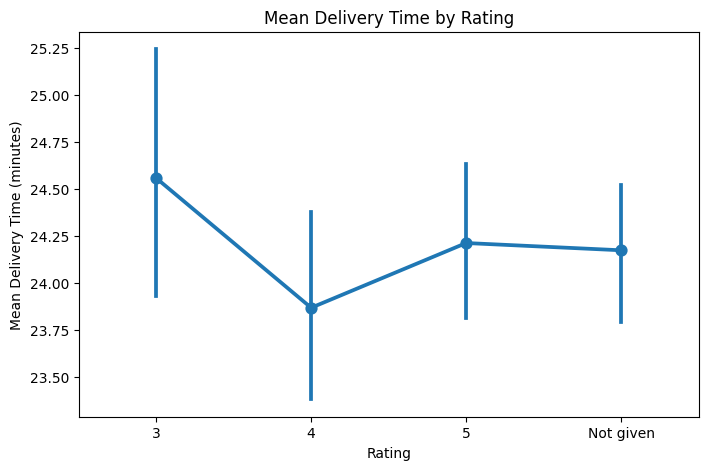

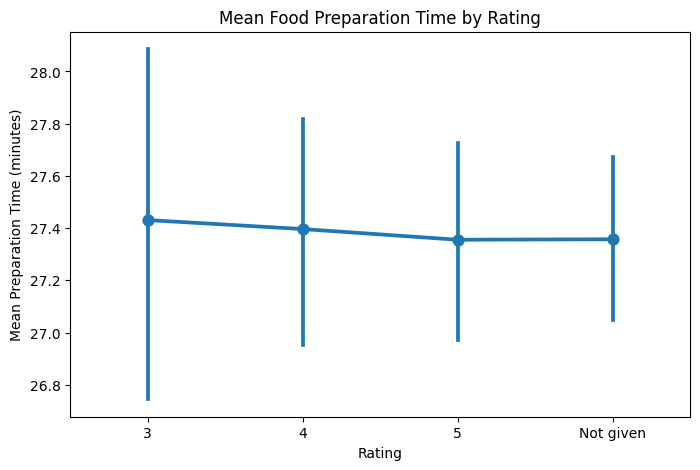

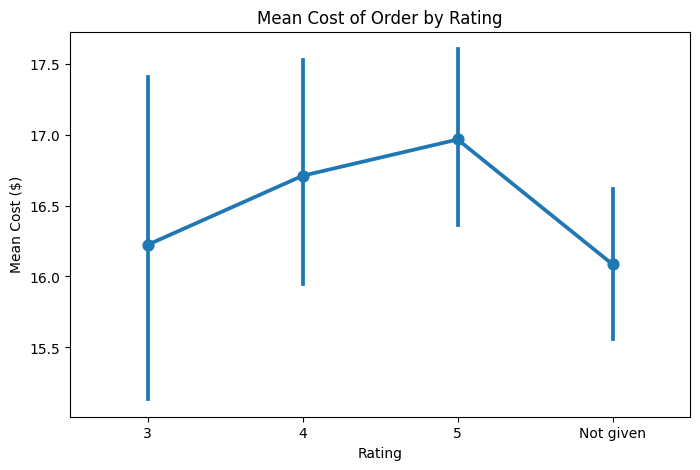

In [40]:
# Write the code here
# ── 1. Correlation heatmap ────────────────────────────────────────────────────
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(8, 5))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral')
plt.title('Correlation Heatmap — Numerical Variables')
plt.show()
# ── 2. Pairplot of all numerical variables ────────────────────────────────────
sns.pairplot(data=df[col_list])
plt.suptitle('Pairplot — Numerical Variables', y=1.02)
plt.show()
# Numerical vs Categorical (7 plots)
# ── 3. Cuisine type vs Cost of the order ─────────────────────────────────────
plt.figure(figsize=(15, 7))
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df, palette='PuBu', hue='cuisine_type', legend=False)
plt.xticks(rotation=60)
plt.title('Cost of Order by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost ($)')
plt.tight_layout()
plt.show()
# ── 4. Cuisine type vs Food preparation time ──────────────────────────────────
plt.figure(figsize=(15, 7))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df, palette='PuBu', hue='cuisine_type', legend=False)
plt.xticks(rotation=60)
plt.title('Food Preparation Time by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Preparation Time (minutes)')
plt.tight_layout()
plt.show()
# ── 5. Day of the week vs Delivery time ──────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Delivery Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.show()
# ── 6. Day of the week vs Cost of the order ───────────────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_the_week', y='cost_of_the_order', data=df)
plt.title('Cost of Order by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Cost ($)')
plt.show()
# ── 7. Rating vs Delivery time ────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.pointplot(x='rating', y='delivery_time', data=df, order=['3', '4', '5', 'Not given'])
plt.title('Mean Delivery Time by Rating')
plt.xlabel('Rating')
plt.ylabel('Mean Delivery Time (minutes)')
plt.show()
# ── 8. Rating vs Food preparation time ───────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.pointplot(x='rating', y='food_preparation_time', data=df, order=['3', '4', '5', 'Not given'])
plt.title('Mean Food Preparation Time by Rating')
plt.xlabel('Rating')
plt.ylabel('Mean Preparation Time (minutes)')
plt.show()
# ── 9. Rating vs Cost of the order ───────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.pointplot(x='rating', y='cost_of_the_order', data=df, order=['3', '4', '5', 'Not given'])
plt.title('Mean Cost of Order by Rating')
plt.xlabel('Rating')
plt.ylabel('Mean Cost ($)')
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [42]:
# Write the code here
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype('int')
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending=False).reset_index()
df_rating_count.head()
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name']
rest_names
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()
df_mean_4_rating = df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending=False).reset_index().dropna()
df_mean_4_rating
df_avg_rating_greater_than_4 = df_mean_4_rating[df_mean_4_rating['rating'] > 4].sort_values(by='rating', ascending=False).reset_index(drop=True)

df_avg_rating_greater_than_4

,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


Observations: The above 4 restaurents meets both conditions of having a rating count of more than 50 and the average rating greater than 4

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [44]:
# Write the code here
# Step 1: Defining a function
def compute_rev(x):
    if x > 20:
        return x * 0.25      # 25% commission on orders > 20$
    elif x > 5:
        return x * 0.15      # 15% commission on orders > 5$
    else:
        return 0             # no commission on orders <= 5


df['Revenue'] = df['cost_of_the_order'].apply(compute_rev)
df.head()
total_rev = df['Revenue'].sum()
print('The net revenue generated by the company across all orders is $', round(total_rev, 2))

The net revenue generated by the company across all orders is $ 6166.3


#### Observations:
                 The generated income across all orders is 6166.3 dollars


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [47]:
# Write the code here
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
df.head()
df_greater_than_60 = df[df['total_time'] > 60]
print('Number of orders exceeding 60 minutes:', df_greater_than_60.shape[0])
percentage_60 = (df_greater_than_60.shape[0] / df.shape[0]) * 100
print('Percentage of orders exceeding 60 minutes:', round(percentage_60, 2), '%')



Number of orders exceeding 60 minutes: 200
Percentage of orders exceeding 60 minutes: 10.54 %


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

The mean delivery time on weekdays is around 28.34 minutes
The mean delivery time on weekends is around 22.47 minutes


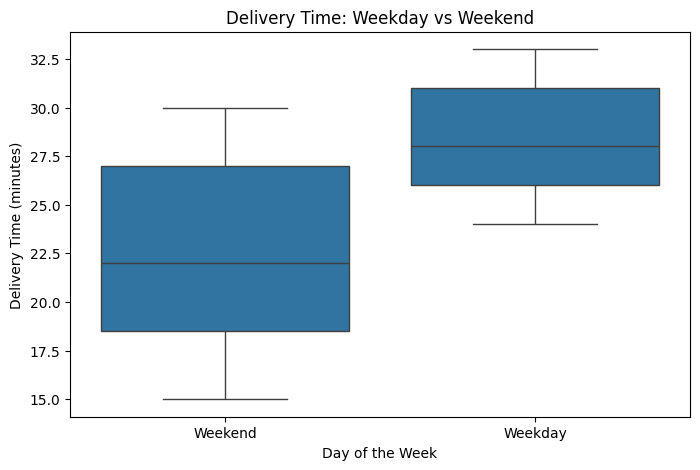

In [50]:
# Write the code here
print('The mean delivery time on weekdays is around',
      round(df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean(), 2),
      'minutes')
print('The mean delivery time on weekends is around',
      round(df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean(), 2),
      'minutes')
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Delivery Time: Weekday vs Weekend')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.show()

#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions: of the 1899 orders that were placed, 178 restaurants took orders from 1200 different customers for 14 different kinds of food. American and Japanese food contributed up to 56% of the total, which was the most money. 11.5% of the orders from Shake Shack. The company made $6,166.30 in profit. of the three restaurants, Shake Shack made the most money, bringing in $3,580, followed by Blue Ribbon at $1,904, while The Meatball Shop made $2,145. From an operational point of view, it is clear 10.54% of orders take longer than 60 minutes, isn't good for customer experience.



### Recommendations: The Meatball Shop, Blue Riboon Fried Chieck,Shake Snake, and Blue Ribbon Sushi should be given more advertisement budget since they are ahead of the rest when it comes to quality and sales. The orders that took more than 60 minutes should be investigated and may require more interventions to improve their performance. The top three customers should be incentivise beyond the 20% voucher.

*  

---